# Cover-Call · Original research notebook

![Strategy schematic](../assets/teaser.png)

[Project README](../README.md) · [Local reproduction](../docs/REPRODUCE.md) · [New Quickstart](../Quickstart.ipynb)

> Original research code and saved outputs follow. Computational cells and execution counts are retained. Original reports are separate from this verification; read the data and dependency requirements before execution.


loading data...
Underlying shape: (1040, 8)
Option shape: (91854, 16)

Strategy type: wheel
OTM strike level: 1

Start backtest Wheel (OTM level1)...
2022-10-10

[SELL PUT] 2022-10-10 00:00:00 10004545
  Strike price: 5.75
  Premium: 0.3273
  Expiry date: 2022-12-16
2022-10-11
2022-10-12
2022-10-13
2022-10-14
2022-10-17
2022-10-18
2022-10-19
2022-10-20
2022-10-21
2022-10-24
2022-10-25
2022-10-26
2022-10-27
2022-10-28
2022-10-31
2022-11-01
2022-11-02
2022-11-03
2022-11-04
2022-11-07
2022-11-08
2022-11-09
2022-11-10
2022-11-11
2022-11-14
2022-11-15
2022-11-16
2022-11-17
2022-11-18
2022-11-21
2022-11-22
2022-11-23
2022-11-24
2022-11-25
2022-11-28
2022-11-29
2022-11-30
2022-12-01
2022-12-02
2022-12-05
2022-12-06
2022-12-07
2022-12-08
2022-12-09
2022-12-12
2022-12-13
2022-12-14
2022-12-15
2022-12-16

[EXERCISE] Expiry date: 2022-12-16 | 当前Date: 2022-12-16 00:00:00
Short Put expires unassigned | 10004545
[After exercise] ETF position: 0  units
[PHASE CHANGE] Cash Phase
2022-12-19
2022-12-20


/var/folders/w4/mkt1vn7n1t92zjgxb87ch6dw0000gn/T/ipykernel_83588/2554031248.py:332: UserWarning: Glyph 34394 (\N{CJK UNIFIED IDEOGRAPH-865A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/w4/mkt1vn7n1t92zjgxb87ch6dw0000gn/T/ipykernel_83588/2554031248.py:332: UserWarning: Glyph 26723 (\N{CJK UNIFIED IDEOGRAPH-6863}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/w4/mkt1vn7n1t92zjgxb87ch6dw0000gn/T/ipykernel_83588/2554031248.py:332: UserWarning: Glyph 21021 (\N{CJK UNIFIED IDEOGRAPH-521D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/w4/mkt1vn7n1t92zjgxb87ch6dw0000gn/T/ipykernel_83588/2554031248.py:332: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/w4/mkt1vn7n1t92zjgxb87ch6dw0000gn/T/ipykernel_83588/2554031248.py:332: UserWarning: Glyph 36164 (\N{CJK UNIFIED IDEOGRAPH-8D44}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/w4

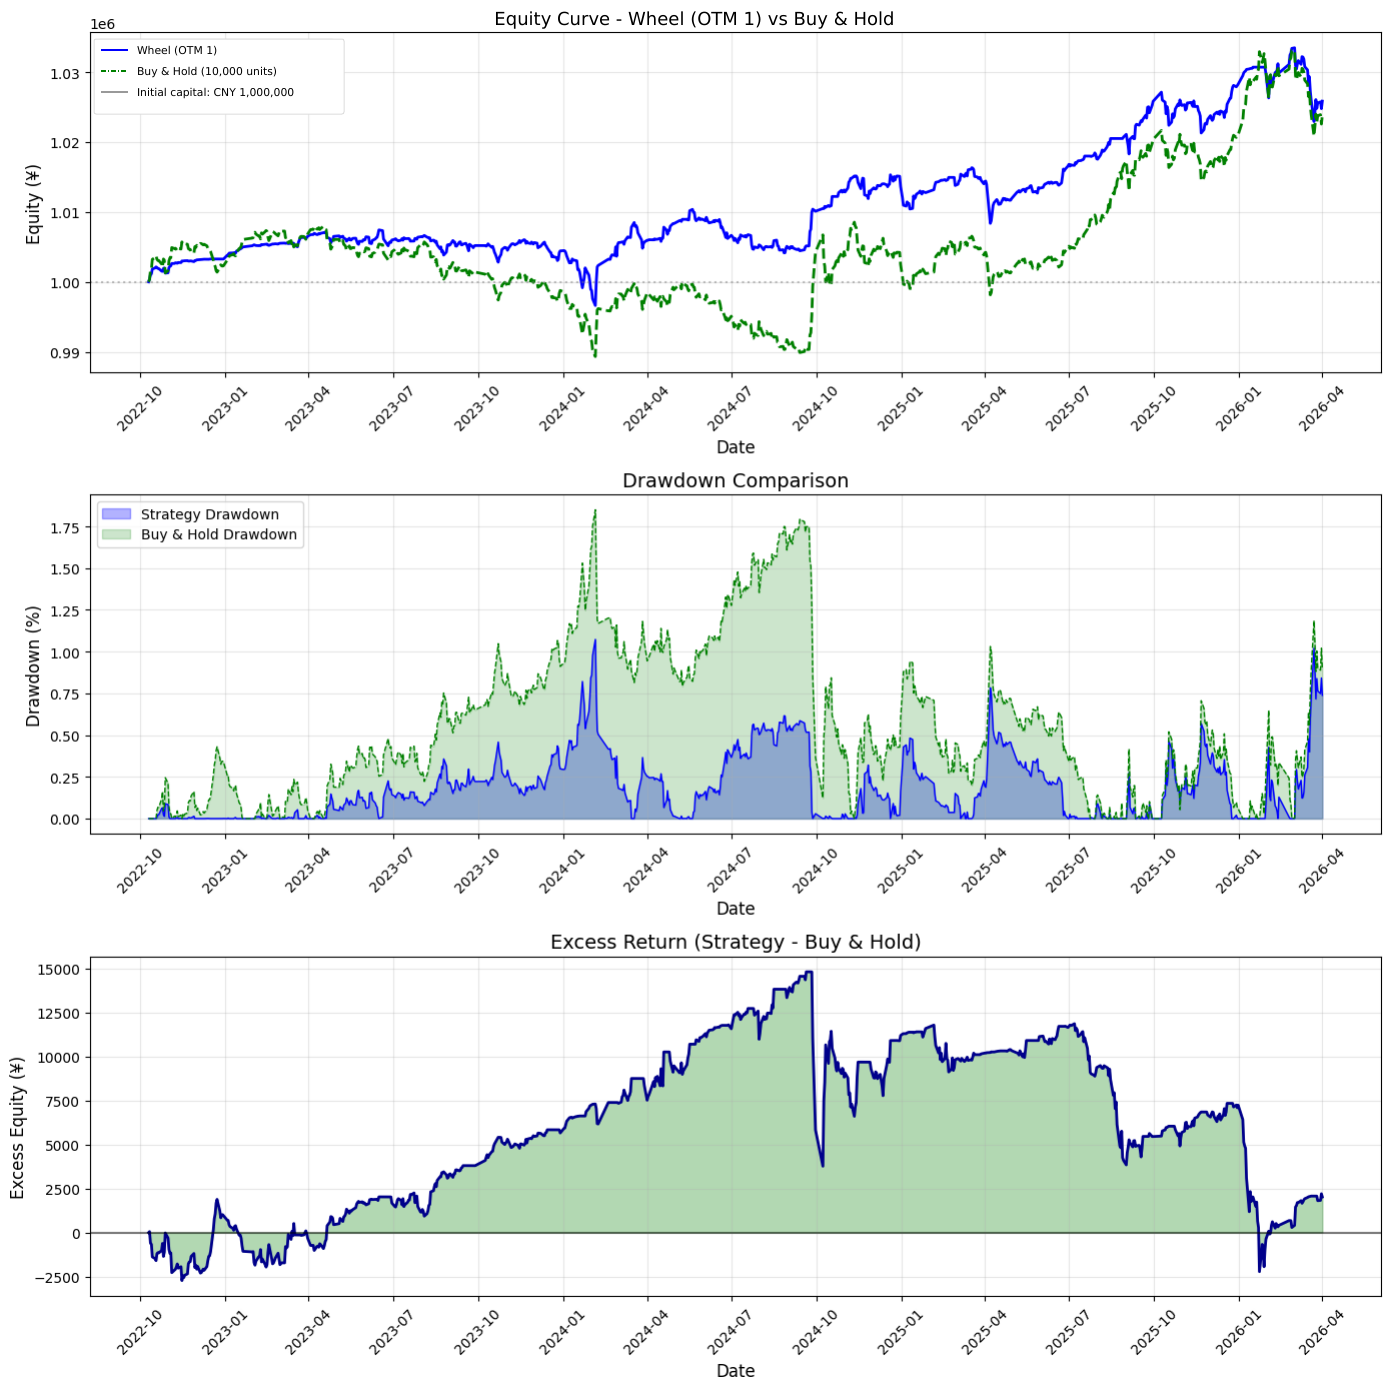


Backtest complete！


In [7]:
import importlib
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

# ============================================================
# 1. Reload modules
# ============================================================
import option_builder.option_process as option_process_module
import data.loader as loader_module
import engine.engine as engine_module
import portfolio.portfolio as portfolio_module
import strategy.template_option_strategy as template_option_strategy_module
import strategy.template_underlying_strategy as template_underlying_strategy_module
import strategy.cover_call_strategy as cover_call_strategy_module
import strategy.option_wheel_strategy as option_wheel_strategy_module  # Newly added

importlib.reload(option_process_module)
importlib.reload(loader_module)
importlib.reload(engine_module)
importlib.reload(portfolio_module)
importlib.reload(template_option_strategy_module)
importlib.reload(template_underlying_strategy_module)
importlib.reload(cover_call_strategy_module)
importlib.reload(option_wheel_strategy_module)  # Newly added

from option_builder.option_process import OptionDatabase
from data import loader
from engine.engine import BacktestEngine
from portfolio.portfolio import Portfolio
from strategy.template_underlying_strategy import TemplateUnderlyingStrategy
from strategy.cover_call_strategy import CoverCallStrategy
from strategy.option_wheel_strategy import OptionWheelStrategy  # Newly added

# ============================================================
# 2. Parameter configuration
# ============================================================
FILE_PATH_UNDERLYING = "500ETF/510500_underlying.csv"
FILE_PATH_OPTION = "500ETF/510500_option_prices.csv"

# ===== Strategy selection =====
# Options: 'cover_call' or 'wheel'
STRATEGY_TYPE = 'wheel'  # Switch strategy: 'cover_call' or 'wheel'

# ===== Backtest parameters =====
INITIAL_CASH = 1_000_000  # Initial capital: 1,000,000
OPTION_QUANTITY = 1       # Number of option contracts
LEVEL = 1                 # Strike level: 1=one OTM, 2=two OTM, 3=three OTM, -1=one ITM

# ===== Backtest date range =====
START_DATE = "2022-10-01"
END_DATE = "2026-04-01"

print("loading data...")

df_underlying = loader.load_underlying_data(FILE_PATH_UNDERLYING)
df_option = loader.load_option_data(FILE_PATH_OPTION)

print(f"Underlying shape: {df_underlying.shape}")
print(f"Option shape: {df_option.shape}")

option_db = OptionDatabase(underlying_df=df_underlying, option_df=df_option)

# ============================================================
# 3. Function to backtest one strategy
# ============================================================
def run_backtest(strategy_type='cover_call', level=1, cash=INITIAL_CASH, quantity=OPTION_QUANTITY):
    """
    Run the backtest for the selected strategy
    
    Parameters:
    -----------
    strategy_type: str
        'cover_call' or 'wheel'
    level: int
        OTM strike level
    cash: float
        Initial capital
    quantity: int
        Number of option contracts
    """
    
    # Create Portfolio
    portfolio = Portfolio(
        cash=cash,
        multiplier=10000,
        option_cost=0.8,
        etf_cost_rate=0.0001,
        etf_min_cost=0,
        option_slippage=0.001,
        etf_slippage=0
    )
    
    # ===== Create the appropriate strategy for the selected type =====
    if strategy_type == 'cover_call':
        option_strategy = CoverCallStrategy(
            quantity=quantity,
            etf_quantity=quantity,
            level=level
        )
        strategy_name = f"Covered Call (OTM level{level})"
    elif strategy_type == 'wheel':
        option_strategy = OptionWheelStrategy(
            quantity=quantity,
            level=level
        )
        strategy_name = f"Wheel (OTM level{level})"
    else:
        raise ValueError(f"Unknown strategy type: {strategy_type}")
    
    underlying_strategy = TemplateUnderlyingStrategy()
    
    # Create the engine
    engine = BacktestEngine(
        option_db=option_db,
        option_strategy=option_strategy,
        underlying_strategy=underlying_strategy,
        portfolio=portfolio
    )
    
    engine.prepare_timeline(start=START_DATE, end=END_DATE)
    
    print(f"\nStart backtest {strategy_name}...")
    results = engine.run()
    results['timestamp'] = pd.to_datetime(results['timestamp'])
    
    return results, portfolio, engine, strategy_name

# ============================================================
# 4. Run the strategy
# ============================================================
print(f"\n{'='*60}")
print(f"Strategy type: {STRATEGY_TYPE}")
print(f"OTM strike level: {LEVEL}")
print(f"{'='*60}")

results_strategy, portfolio_strategy, engine_strategy, strategy_name = run_backtest(
    strategy_type=STRATEGY_TYPE,
    level=LEVEL
)

print(f"\n{strategy_name} Backtest complete！")

# ============================================================
# 5. Calculate Buy & Hold NAV
# ============================================================
print("\nCalculate the Buy & Hold comparison...")

bh_prices = []
bh_dates = []

for date in engine_strategy.timeline:
    date_str = pd.Timestamp(date).strftime('%Y-%m-%d')
    spot = option_db.get_spot(date_str)
    if spot is not None:
        bh_prices.append(spot)
        bh_dates.append(date_str)

bh_prices = pd.Series(bh_prices, index=pd.to_datetime(bh_dates))

etf_shares_bh = 10000
initial_etf_price = bh_prices.iloc[0]
bh_initial_cost = etf_shares_bh * initial_etf_price
bh_cash_remaining = INITIAL_CASH - bh_initial_cost
bh_equity = bh_prices * etf_shares_bh + bh_cash_remaining
bh_equity_aligned = bh_equity.reindex(results_strategy['timestamp'], method='ffill')
results_strategy['bh_equity'] = bh_equity_aligned.values

# ============================================================
# 6. Analyze results
# ============================================================
print("\n" + "="*60)
print(f"Backtest result analysis - {strategy_name}")
print("="*60)

# Strategy statistics
initial_equity = results_strategy["equity"].iloc[0]
final_equity = results_strategy["equity"].iloc[-1]
total_return = (final_equity / initial_equity - 1) * 100
max_equity = results_strategy["equity"].max()
min_equity = results_strategy["equity"].min()
max_drawdown = (max_equity - min_equity) / max_equity * 100

days = len(results_strategy)
annual_return = ((final_equity / initial_equity) ** (252 / days) - 1) * 100 if days > 0 else 0

# Sharpe ratio assuming a zero risk-free rate
returns = results_strategy["equity"].pct_change().dropna()
sharpe_ratio = (returns.mean() / returns.std()) * np.sqrt(252) if returns.std() > 0 else 0

# Buy & Hold statistics
initial_equity_bh = results_strategy["bh_equity"].iloc[0]
final_equity_bh = results_strategy["bh_equity"].iloc[-1]
total_return_bh = (final_equity_bh / initial_equity_bh - 1) * 100
max_equity_bh = results_strategy["bh_equity"].max()
min_equity_bh = results_strategy["bh_equity"].min()
max_drawdown_bh = (max_equity_bh - min_equity_bh) / max_equity_bh * 100
annual_return_bh = ((final_equity_bh / initial_equity_bh) ** (252 / days) - 1) * 100 if days > 0 else 0

print(f"\n📊 NAV statistics comparison:")
print("-" * 70)
print(f"{'指标':<25} {strategy_name:>20} {'Buy & Hold':>20}")
print("-" * 70)
print(f"{'Initial capital':<25} {initial_equity:>20,.2f} {initial_equity_bh:>20,.2f}")
print(f"{'Final capital':<25} {final_equity:>20,.2f} {final_equity_bh:>20,.2f}")
print(f"{'总收益率':<25} {total_return:>19.2f}% {total_return_bh:>19.2f}%")
print(f"{'年化收益率':<25} {annual_return:>19.2f}% {annual_return_bh:>19.2f}%")
print(f"{'最大净值':<25} {max_equity:>20,.2f} {max_equity_bh:>20,.2f}")
print(f"{'最小净值':<25} {min_equity:>20,.2f} {min_equity_bh:>20,.2f}")
print(f"{'Maximum drawdown':<25} {max_drawdown:>19.2f}% {max_drawdown_bh:>19.2f}%")
print(f"{'夏普比率':<25} {sharpe_ratio:>19.2f} {'--':>20}")
print("-" * 70)

excess_return = total_return - total_return_bh
excess_annual = annual_return - annual_return_bh
print(f"\n📈 Excess return ({strategy_name} vs Buy & Hold):")
print(f"  Total excess return: {excess_return:+.2f}%")
print(f"  Annualized excess return: {excess_annual:+.2f}%")

# ============================================================
# 7. Analyze trade records
# ============================================================
print("\n" + "="*60)
print(f"{strategy_name} Trade record analysis")
print("="*60)

df_option_trades = pd.DataFrame(portfolio_strategy.option_trade_history)
if not df_option_trades.empty:
    print(f"\n📈 Option trades:")
    print(f"  Number of trades: {len(df_option_trades)}")
    print(f"  Total commission: ¥{df_option_trades['cost'].sum():.2f}")
    buy_qty = df_option_trades[df_option_trades['quantity']>0]['quantity'].sum()
    sell_qty = abs(df_option_trades[df_option_trades['quantity']<0]['quantity'].sum())
    print(f"  Buy contracts: {buy_qty}")
    print(f"  Sell contracts: {sell_qty}")
    
    # Statistics by option type
    call_trades = df_option_trades[df_option_trades['option_type'] == 'Call']
    put_trades = df_option_trades[df_option_trades['option_type'] == 'Put']
    if not call_trades.empty:
        print(f"  Call trades: {len(call_trades)}  trades")
    if not put_trades.empty:
        print(f"  Put trades: {len(put_trades)}  trades")
    
    print("\n  First five trades:")
    print(df_option_trades[['timestamp', 'id', 'quantity', 'trade_price', 'option_type']].head())

df_underlying_trades = pd.DataFrame(portfolio_strategy.underlying_trade_history)
if not df_underlying_trades.empty:
    print(f"\n📈 ETF trades:")
    print(f"  Number of trades: {len(df_underlying_trades)}")
    print(f"  Total commission: ¥{df_underlying_trades['cost'].sum():.2f}")
    print(df_underlying_trades[['timestamp', 'quantity', 'trade_price']].head())

df_closed = pd.DataFrame(portfolio_strategy.closed_trade_history)
if not df_closed.empty:
    total_pnl = df_closed['pnl'].sum()
    win_count = len(df_closed[df_closed['pnl'] > 0])
    loss_count = len(df_closed[df_closed['pnl'] < 0])
    win_rate = win_count / len(df_closed) * 100 if len(df_closed) > 0 else 0
    print(f"\n💰 Closed-trade PnL:")
    print(f"  Total trades: {len(df_closed)}")
    print(f"  Total PnL: ¥{total_pnl:,.2f}")
    print(f"  Average PnL: ¥{df_closed['pnl'].mean():.2f}")
    print(f"  Largest profit: ¥{df_closed['pnl'].max():.2f}")
    print(f"  Largest loss: ¥{df_closed['pnl'].min():.2f}")
    print(f"  Profitable trades: {win_count}")
    print(f"  Losing trades: {loss_count}")
    print(f"  Win rate: {win_rate:.1f}%")

# ============================================================
# 8. Plot NAV curves
# ============================================================
fig, axes = plt.subplots(3, 1, figsize=(14, 14))

# Subplot 1: NAV curves
ax1 = axes[0]
ax1.plot(results_strategy["timestamp"], results_strategy["equity"], linewidth=2, 
         color='blue', label=strategy_name)
ax1.plot(results_strategy["timestamp"], results_strategy["bh_equity"], linewidth=2, 
         color='green', linestyle='--', label='Buy & Hold (10000 shares)')
ax1.axhline(y=INITIAL_CASH, color='gray', linestyle=':', alpha=0.5, label=f'Initial capital: ¥{INITIAL_CASH:,.0f}')
ax1.set_title(f"Equity Curve - {strategy_name} vs Buy & Hold", fontsize=14)
ax1.set_ylabel("Equity (¥)", fontsize=12)
ax1.set_xlabel("Date", fontsize=12)
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)

# Subplot 2: Drawdown
ax2 = axes[1]
rolling_max = results_strategy["equity"].cummax()
drawdown = (rolling_max - results_strategy["equity"]) / rolling_max * 100
ax2.fill_between(results_strategy["timestamp"], 0, drawdown, color='blue', alpha=0.3, label='Strategy Drawdown')
ax2.plot(results_strategy["timestamp"], drawdown, color='blue', linewidth=1)

rolling_max_bh = results_strategy["bh_equity"].cummax()
drawdown_bh = (rolling_max_bh - results_strategy["bh_equity"]) / rolling_max_bh * 100
ax2.fill_between(results_strategy["timestamp"], 0, drawdown_bh, color='green', alpha=0.2, label='Buy & Hold Drawdown')
ax2.plot(results_strategy["timestamp"], drawdown_bh, color='green', linewidth=1, linestyle='--')

ax2.set_title("Drawdown Comparison", fontsize=14)
ax2.set_ylabel("Drawdown (%)", fontsize=12)
ax2.set_xlabel("Date", fontsize=12)
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)

# Subplot 3: Excess return
ax3 = axes[2]
excess_equity = results_strategy["equity"] - results_strategy["bh_equity"]
ax3.fill_between(results_strategy["timestamp"], 0, excess_equity, 
                  color='green' if excess_equity.iloc[-1] >= 0 else 'red', alpha=0.3)
ax3.plot(results_strategy["timestamp"], excess_equity, color='darkblue', linewidth=2)
ax3.axhline(y=0, color='black', linestyle='-', alpha=0.5)
ax3.set_title("Excess Return (Strategy - Buy & Hold)", fontsize=14)
ax3.set_ylabel("Excess Equity (¥)", fontsize=12)
ax3.set_xlabel("Date", fontsize=12)
ax3.grid(True, alpha=0.3)

ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax3.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("Backtest complete！")
print("="*60)


Multi-Level Comparison - Strategy: wheel
OTM Levels: [-2, -1, 0, 1, 2, 3]

Running wheel strategy (OTM Level: -2)...

Start backtest Wheel (OTM level-2)...
2022-10-10

[SELL PUT] 2022-10-10 00:00:00 10004542
  Strike price: 5.0
  Premium: 0.0568
  Expiry date: 2022-12-16
2022-10-11
2022-10-12
2022-10-13
2022-10-14
2022-10-17
2022-10-18
2022-10-19
2022-10-20
2022-10-21
2022-10-24
2022-10-25
2022-10-26
2022-10-27
2022-10-28
2022-10-31
2022-11-01
2022-11-02
2022-11-03
2022-11-04
2022-11-07
2022-11-08
2022-11-09
2022-11-10
2022-11-11
2022-11-14
2022-11-15
2022-11-16
2022-11-17
2022-11-18
2022-11-21
2022-11-22
2022-11-23
2022-11-24
2022-11-25
2022-11-28
2022-11-29
2022-11-30
2022-12-01
2022-12-02
2022-12-05
2022-12-06
2022-12-07
2022-12-08
2022-12-09
2022-12-12
2022-12-13
2022-12-14
2022-12-15
2022-12-16

[EXERCISE] Expiry date: 2022-12-16 | 当前Date: 2022-12-16 00:00:00
Short Put expires unassigned | 10004542
[After exercise] ETF position: 0  units
[PHASE CHANGE] Cash Phase
2022-12-19
2022-

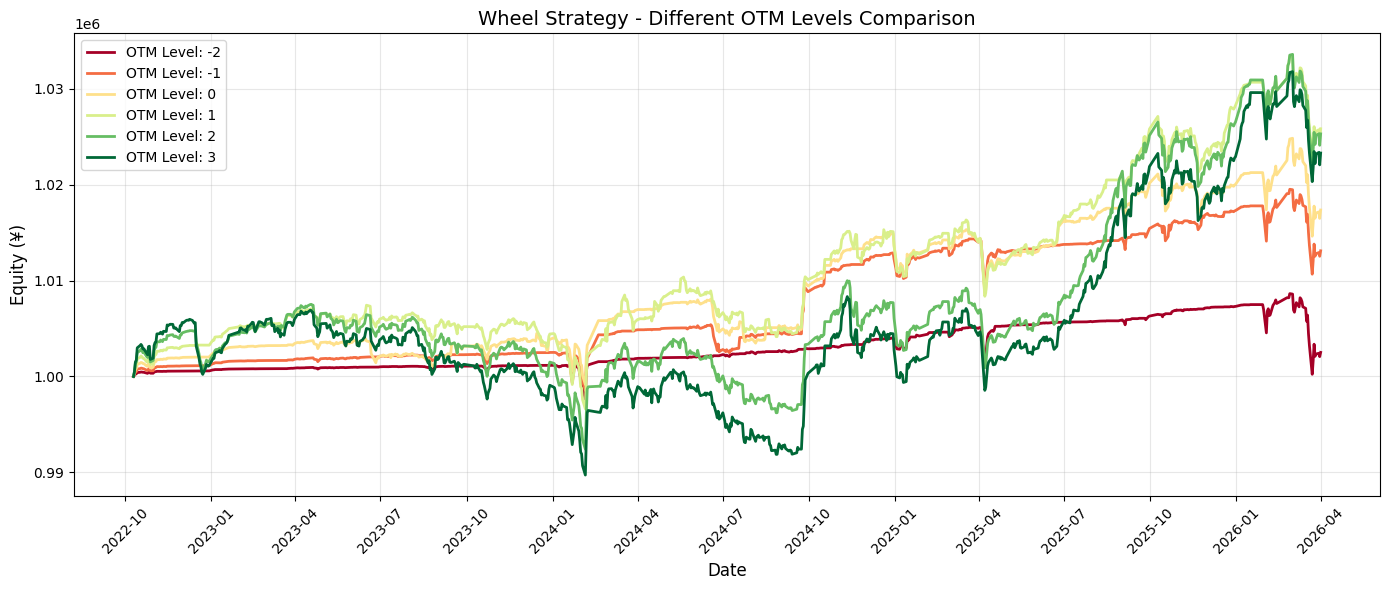


Final Equity Comparison (Wheel)
OTM Level          Final Equity       Total Return
--------------------------------------------------
-2                 1,002,504.58              0.25%
-1                 1,013,104.93              1.31%
0                  1,017,361.73              1.74%
1                  1,025,841.07              2.58%
2                  1,025,306.67              2.53%
3                  1,023,308.63              2.33%


{-2:      timestamp       equity
 0   2022-10-10   999998.632
 1   2022-10-11  1000109.632
 2   2022-10-12  1000247.632
 3   2022-10-13  1000273.632
 4   2022-10-14  1000396.632
 ..         ...          ...
 839 2026-03-26  1002093.582
 840 2026-03-27  1002319.582
 841 2026-03-30  1002418.582
 842 2026-03-31  1002063.582
 843 2026-04-01  1002504.582
 
 [844 rows x 2 columns],
 -1:      timestamp       equity
 0   2022-10-10   999998.085
 1   2022-10-11  1000213.085
 2   2022-10-12  1000462.085
 3   2022-10-13  1000496.085
 4   2022-10-14  1000758.085
 ..         ...          ...
 839 2026-03-26  1012542.934
 840 2026-03-27  1012792.934
 841 2026-03-30  1012922.934
 842 2026-03-31  1012535.934
 843 2026-04-01  1013104.934
 
 [844 rows x 2 columns],
 0:      timestamp       equity
 0   2022-10-10   999997.181
 1   2022-10-11  1000318.181
 2   2022-10-12  1000753.181
 3   2022-10-13  1000818.181
 4   2022-10-14  1001262.181
 ..         ...          ...
 839 2026-03-26  1016504.733
 840 20

In [8]:
# ============================================================
# Optional: Multi-level comparison (supports strategy type)
# ============================================================
def compare_levels(strategy_type='wheel', levels=[1, 2, 3]):
    """
    Compare performance across different OTM levels
    
    Parameters:
    -----------
    strategy_type: str
        'cover_call' or 'wheel'
    levels: list
        List of OTM levels to compare
    """
    results_dict = {}
    
    print(f"\n{'='*60}")
    print(f"Multi-Level Comparison - Strategy: {strategy_type}")
    print(f"OTM Levels: {levels}")
    print(f"{'='*60}")
    
    for level in levels:
        print(f"\nRunning {strategy_type} strategy (OTM Level: {level})...")
        results, _, _, strategy_name = run_backtest(
            strategy_type=strategy_type,
            level=level
        )
        results_dict[level] = results
    
    # Plot comparison chart
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Use color mapping
    colors = plt.cm.RdYlGn(np.linspace(0, 1, len(levels)))
    
    for i, (level, results) in enumerate(results_dict.items()):
        ax.plot(results["timestamp"], results["equity"], 
                linewidth=2, color=colors[i], label=f'OTM Level: {level}')
    
    strategy_label = "Wheel" if strategy_type == 'wheel' else "Cover Call"
    ax.set_title(f"{strategy_label} Strategy - Different OTM Levels Comparison", fontsize=14)
    ax.set_ylabel("Equity (¥)", fontsize=12)
    ax.set_xlabel("Date", fontsize=12)
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)
    
    # Format x-axis
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    # Print final equity comparison
    print("\n" + "="*60)
    print(f"Final Equity Comparison ({strategy_label})")
    print("="*60)
    print(f"{'OTM Level':<12} {'Final Equity':>18} {'Total Return':>18}")
    print("-" * 50)
    for level, results in results_dict.items():
        final_equity = results["equity"].iloc[-1]
        total_return = (final_equity / results["equity"].iloc[0] - 1) * 100
        print(f"{level:<12} {final_equity:>18,.2f} {total_return:>17.2f}%")
    print("="*60)
    
    return results_dict

# ============================================================
# Run multi-level comparison (using current strategy type)
# ============================================================
compare_levels(
    strategy_type=STRATEGY_TYPE,
    levels=[-2, -1, 0, 1, 2, 3]
)